### # Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as  plt
import seaborn as sns

# Imported Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Load Data

In [2]:
# pd.read_csv() loads dataset.
df = pd.read_csv('alzheimers_disease_data.csv')

# shape tells Number of rows (patients) , Number of columns (features)
df.shape

(2149, 35)

In [3]:
# head() shows first 5 records.
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [4]:
# info() Checks data types, Ensures numerical variables are correctly formatted
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [5]:
# isnull().sum() Checks missing values, Missing data can cause model error
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [6]:
# describe() Shows mean, min, max, Helps understand ranges (e.g., MMSE 0–30)
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,0.252210,0.144253,0.150768,0.200558,0.092601,0.148906,134.264774,89.847836,225.197519,124.335944,59.463533,228.281496,14.755132,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,0.434382,0.351428,0.357906,0.400511,0.289940,0.356079,25.949352,17.592496,42.542233,43.366584,23.139174,101.986721,8.613151,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,150.093316,50.230707,20.003434,50.407194,0.005312,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,112.000000,74.000000,190.252963,87.195798,39.095698,137.583222,7.167602,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,91.000000,225.086430,123.342593,59.768237,230.301983,14.441660,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,105.000000,262.031657,161.733733,78.939050,314.839046,22.161028,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,299.993352,199.965665,99.980324,399.941862,29.991381,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Drop informative columns

df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)

### EXPLORATORY DATA ANALYSIS (EDA)

#### Target Variable Analysis

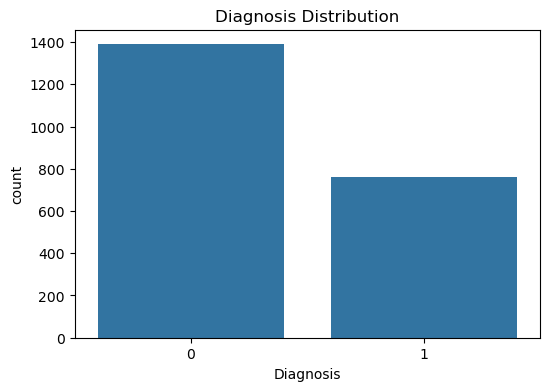

Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df)
plt.title("Diagnosis Distribution")
plt.show()

df['Diagnosis'].value_counts(normalize=True)*100

# Check if dataset is balanced.If one class dominates → need imbalance handling.

### Demographic Analysis

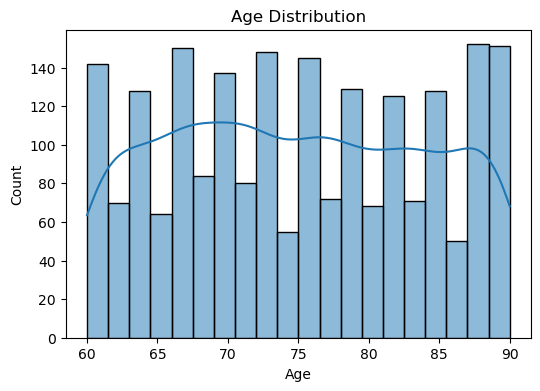

In [9]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# Alzheimer’s risk increases with age, We check if higher ages dominate diagnosis.

### Gender vs Diagnosis

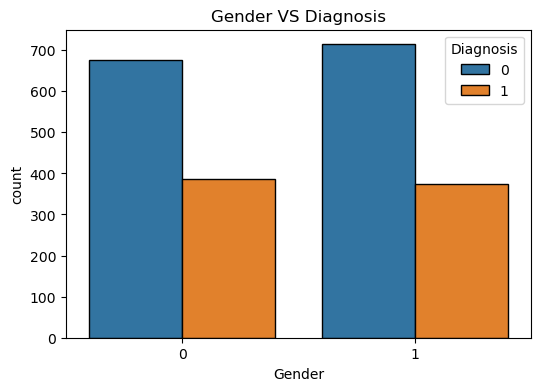

In [10]:
# Compare male vs female Alzheimer’s rates.
# Check if gender is significant factor.

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue= 'Diagnosis', data=df, edgecolor='black')
plt.title('Gender VS Diagnosis')
plt.show()

### Lifestyle Factors Analysis

In [11]:
lifestyle_cols = ['BMI','AlcoholConsumption','PhysicalActivity','DietQuality','SleepQuality'] 

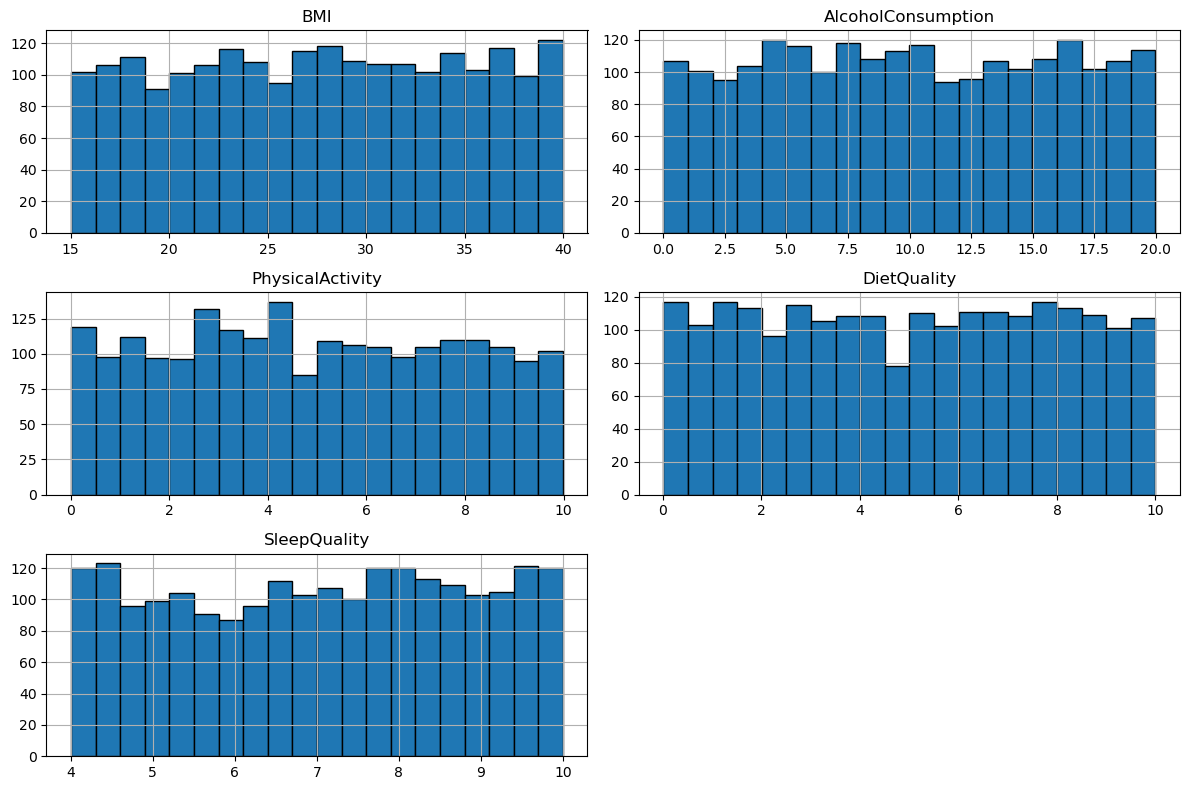

In [12]:
df[lifestyle_cols].hist(figsize=(12,8),bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

# Understand distribution of:
# Obesity (BMI)
# Alcohol intake
# Physical activity
# Diet quality
# Sleep quality

### Lifestyle vs Diagnosis

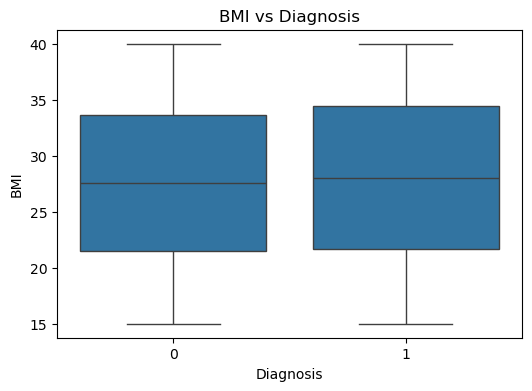

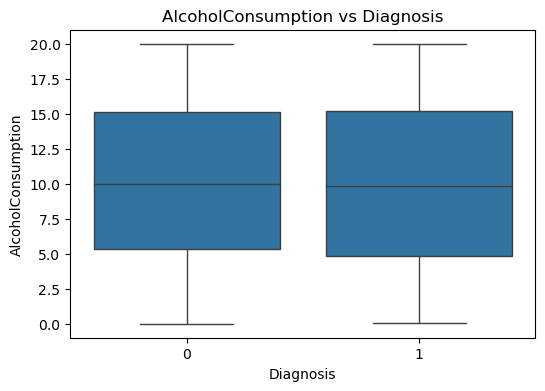

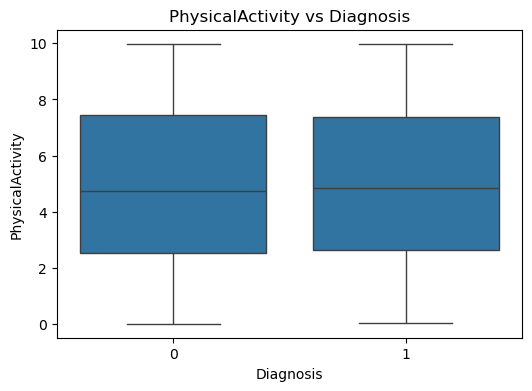

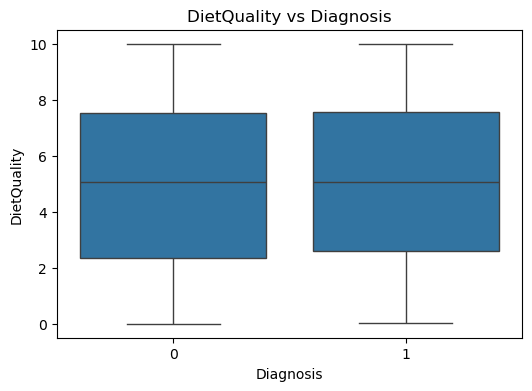

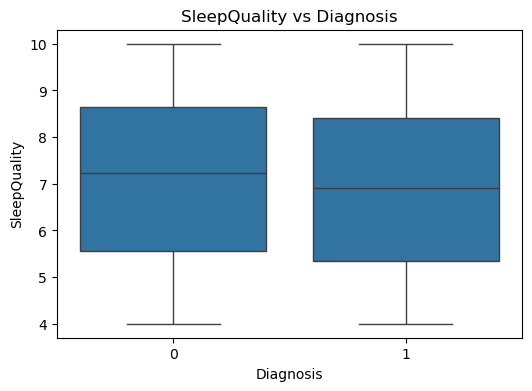

In [13]:
# Compare average values between healthy vs Alzheimer’s patients.
# See if poor lifestyle correlates with diagnosis.

for col in lifestyle_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Diagnosis', y=col, data=df)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

### Medical History Analysis

In [14]:
medical_cols = ['FamilyHistoryAlzheimers','CardiovascularDisease',
                'Diabetes','Depression','HeadInjury','Hypertension']

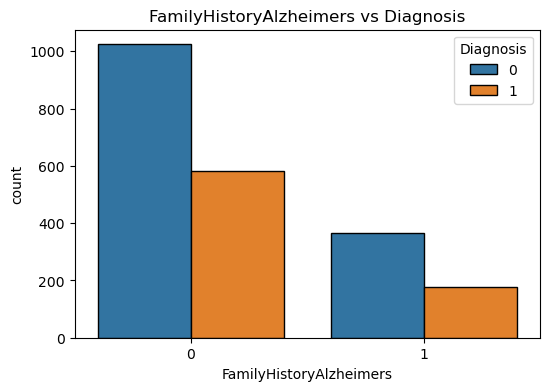

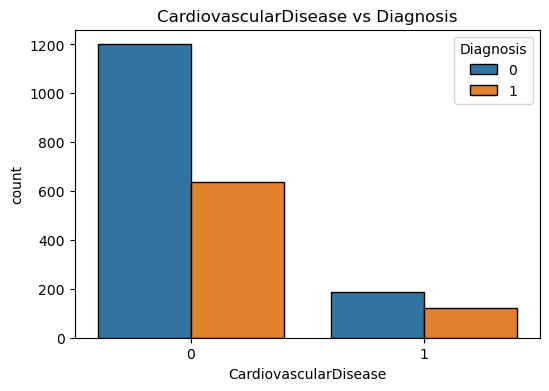

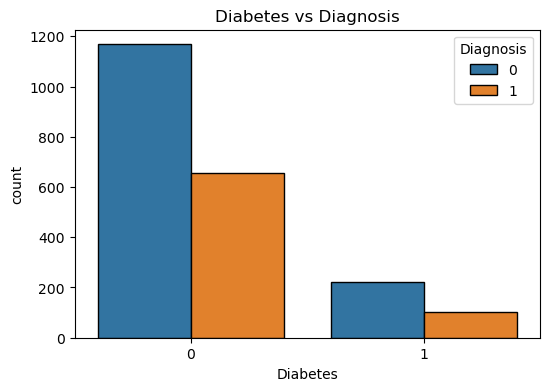

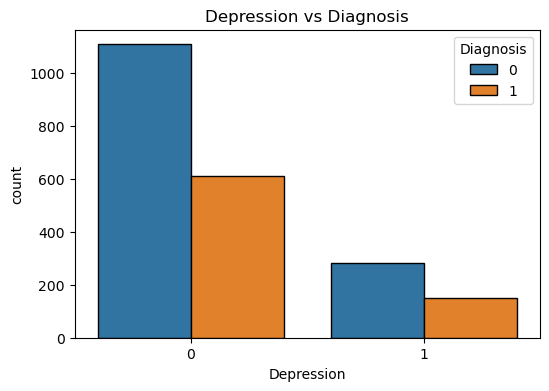

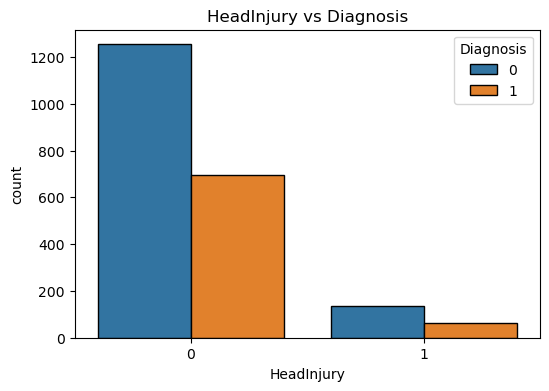

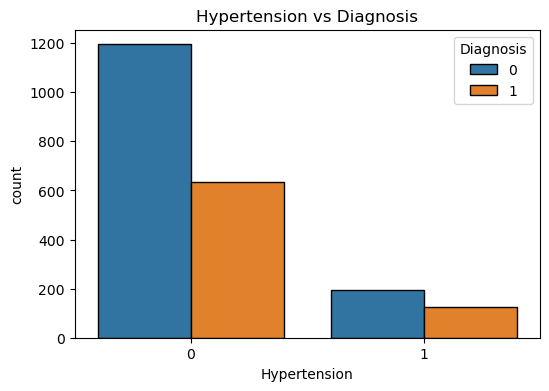

In [15]:

for col in medical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Diagnosis', edgecolor = 'black', data=df)
    plt.title(f"{col} vs Diagnosis")
    plt.show()

# Medical conditions may increase risk.
    
# Example:
# Family history → genetic factor
# Depression → linked with cognitive decline
# Head injury → neurological risk

### Clinical Measurements

In [16]:
clinical_cols = ['SystolicBP','DiastolicBP','CholesterolTotal',
                 'CholesterolLDL','CholesterolHDL',
                 'CholesterolTriglycerides']

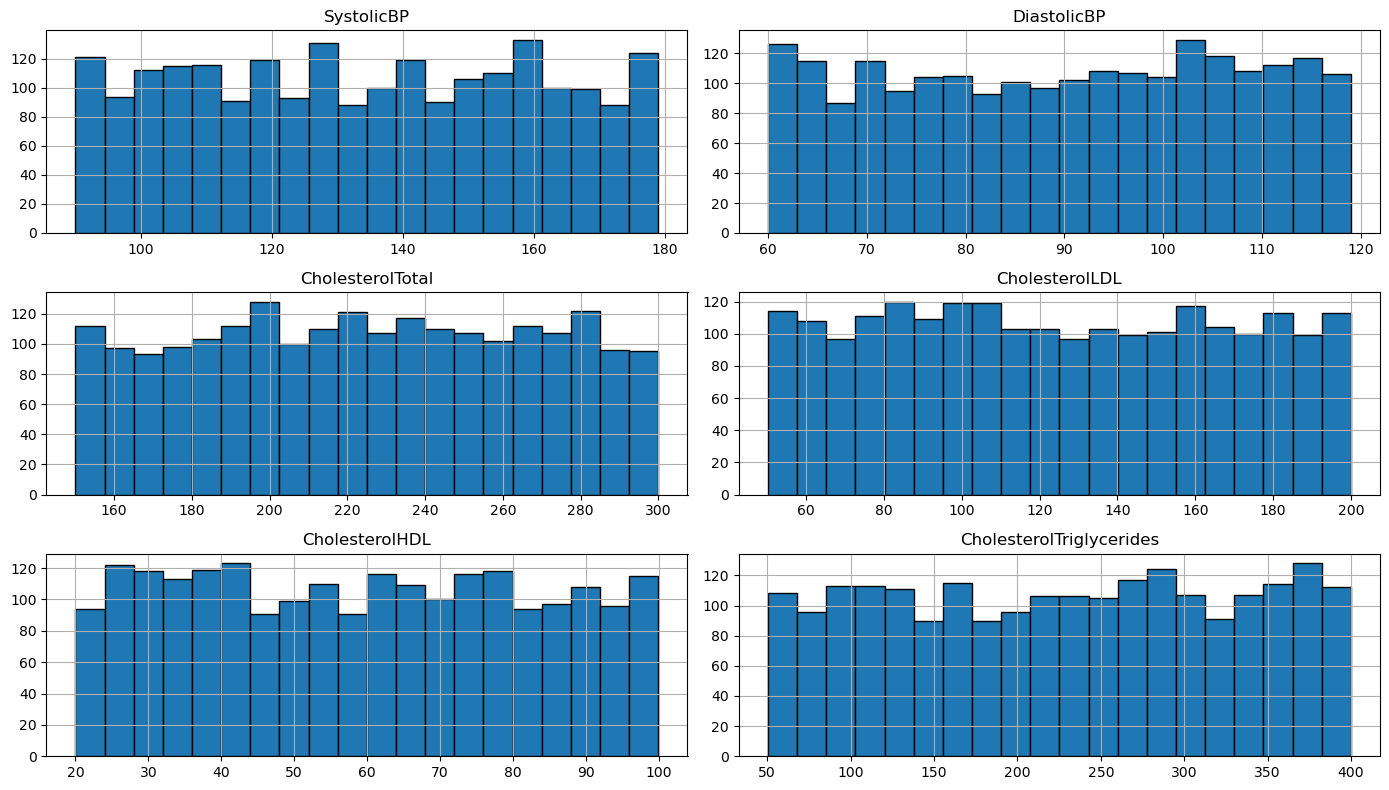

In [17]:
df[clinical_cols].hist(figsize=(14,8), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

# Check if:
# High cholesterol
# Blood pressure
# are associated with diagnosis.

### Cognitive & Functional Assessment

In [18]:
cognitive_cols = ['MMSE','FunctionalAssessment','ADL']

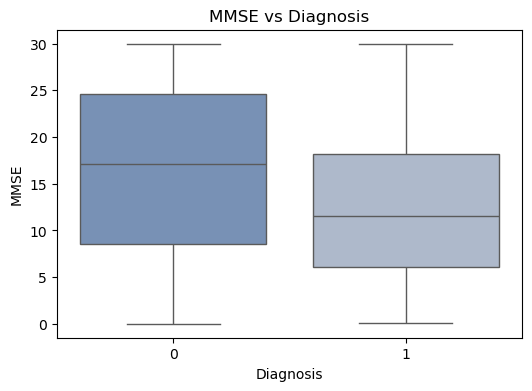

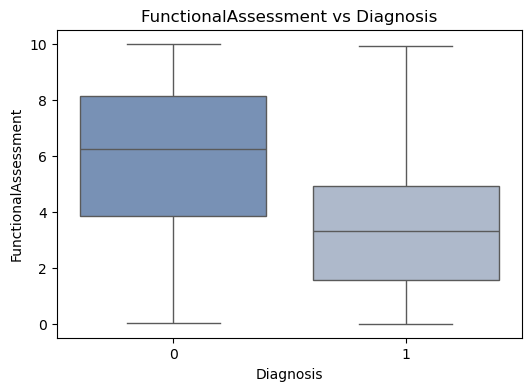

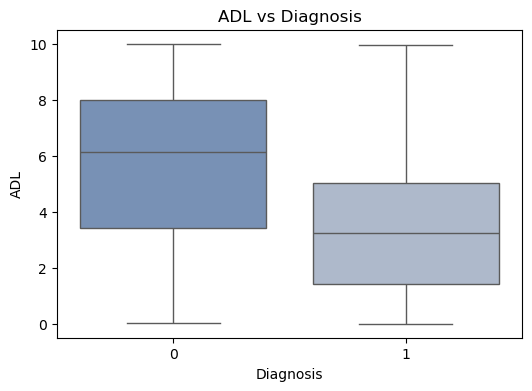

In [19]:
pal = sns.color_palette('vlag')
for col in cognitive_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Diagnosis', y=col, data=df, palette=pal)
    plt.title(f"{col} vs Diagnosis")
    plt.show()


# MMSE measures cognitive ability.
# Lower score → cognitive impairment.
# ADL measures daily living ability.
# Functional decline strongly indicates Alzheimer’s.

### Symptoms Analysis

In [20]:
# Symptoms are strong early indicators.

symptom_cols = ['MemoryComplaints','BehavioralProblems',
                'Confusion','Disorientation',
                'PersonalityChanges','DifficultyCompletingTasks',
                'Forgetfulness']

#If patients with:
# Memory complaints
# Forgetfulness
# Confusion

# show higher diagnosis → important predictive features.

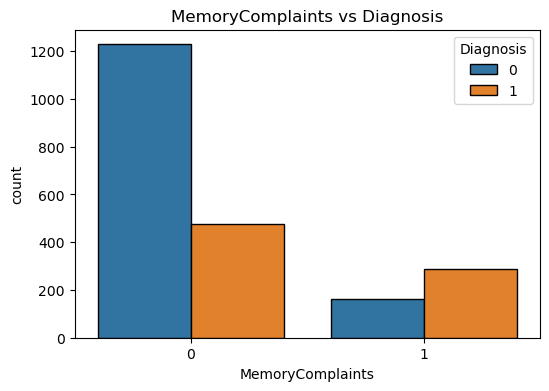

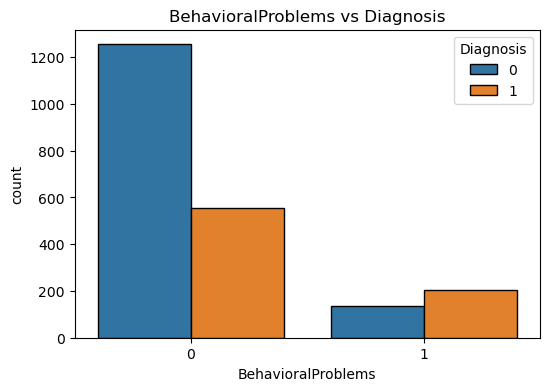

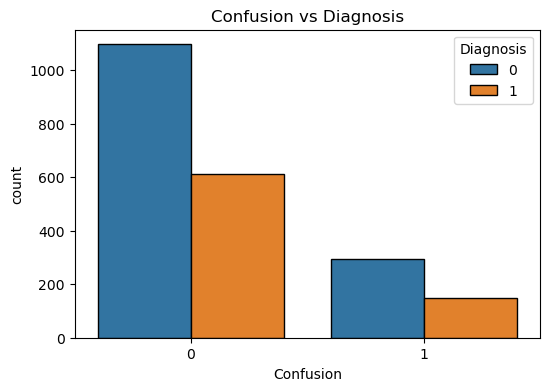

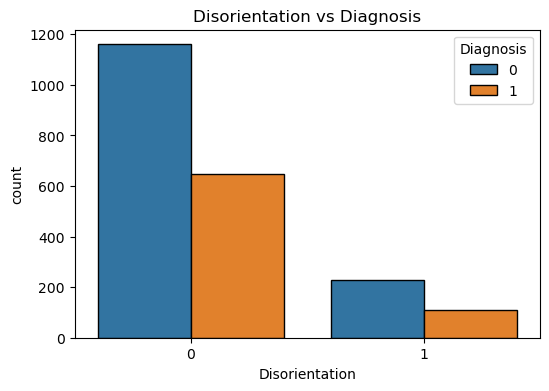

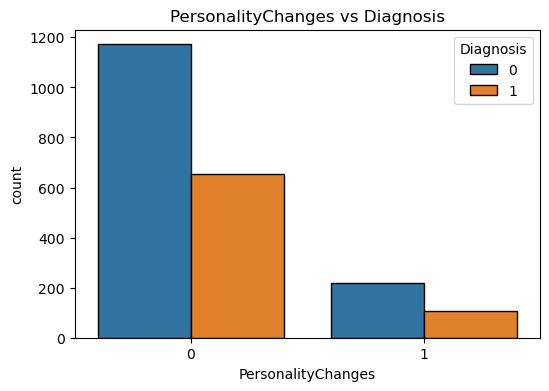

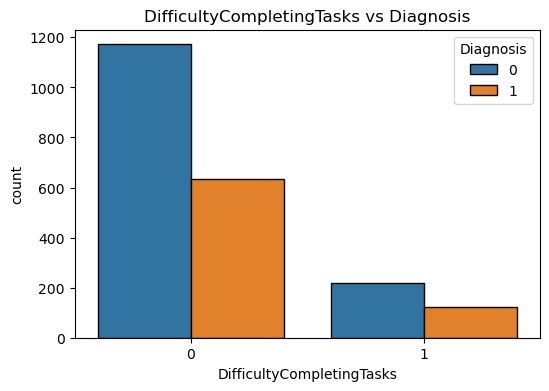

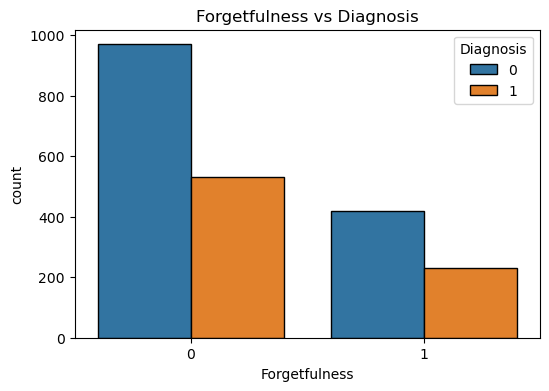

In [21]:
for col in symptom_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Diagnosis', edgecolor='black', data=df)
    plt.title(f"{col} vs Diagnosis")
    plt.show()

### Correlation Analysis

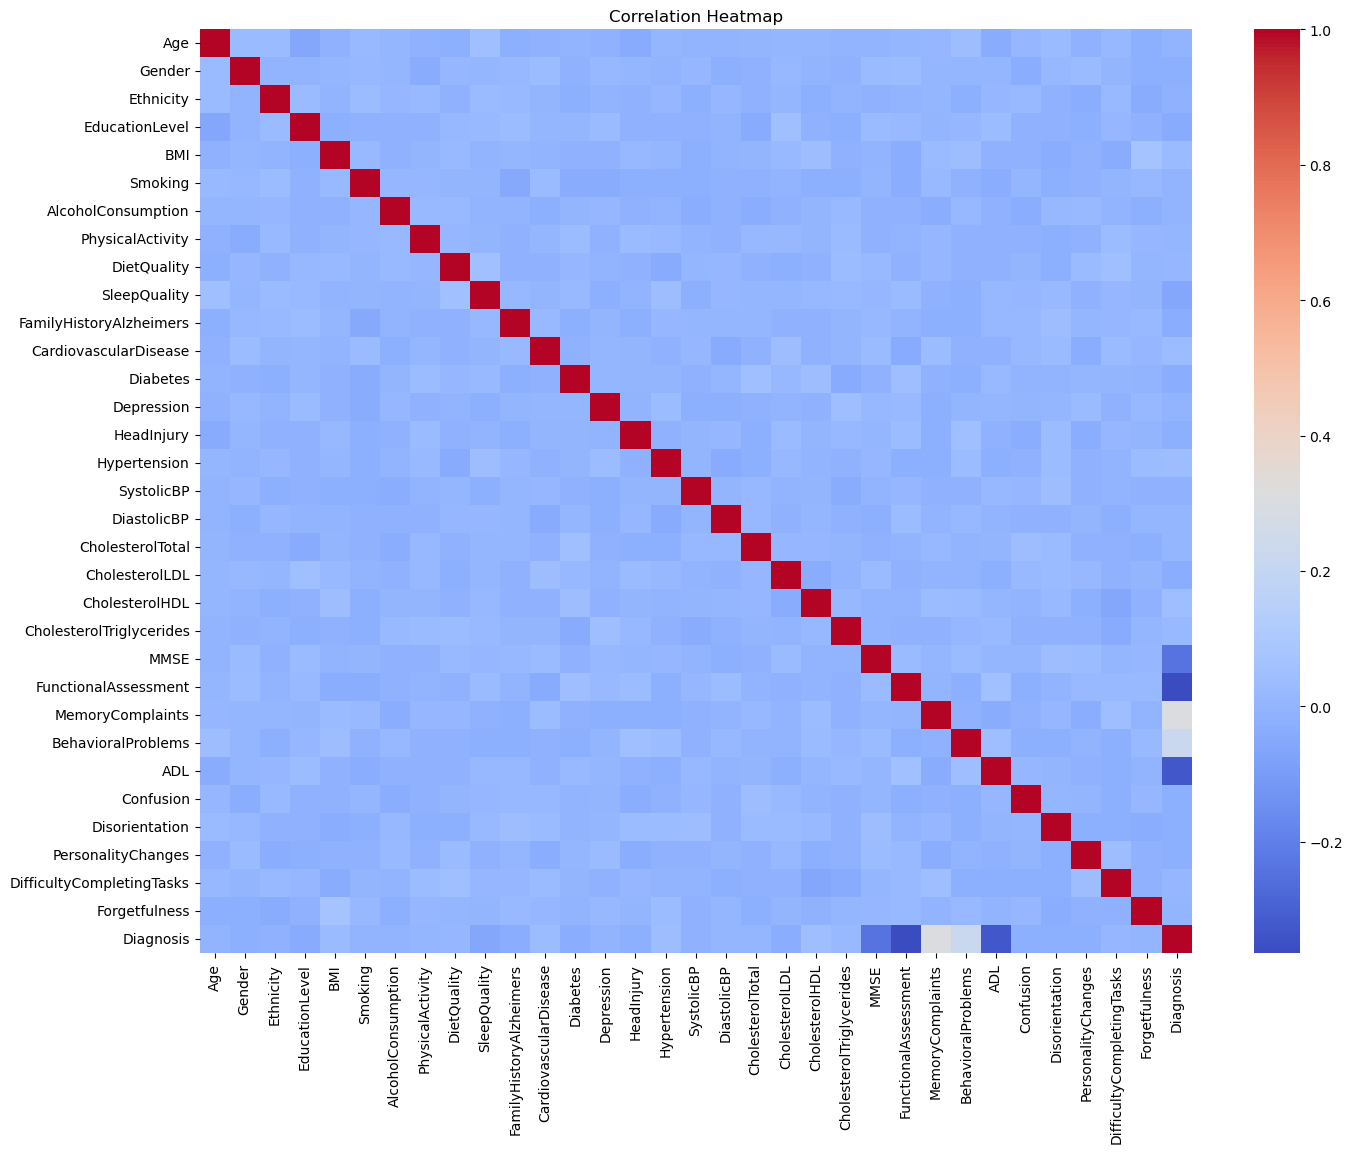

In [22]:
# Understand relationships between features.
# Detect multicollinearity.
# See strongest correlation with Diagnosis.


plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

###  Correlation with Target

In [23]:
# Which factors influence Alzheimer’s most
correlation_with_target = df.corr()['Diagnosis'].sort_values(ascending=False)
print(correlation_with_target)

Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes                    -0.031508
CholesterolL

### Data Preprocessing

In [24]:
# Separate features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# X → Independent variables
# y → Target variable
# Supervised learning requires this separation

In [25]:
# Train-Test Split

X_train, X_test, y_train, y_test, = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model learns on past data and is tested on unseen patients.

In [26]:
print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (1504, 32)
Testing Size: (645, 32)


### Feature Scaling

In [27]:
# Normalize numerical features.

scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

#### Model 1 Logistic Regression

In [29]:
# Logistic Regression Model

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Baseline model
# Easy to interpret
# Good for binary classification
# Logistic Regression It calculates probability

LogisticRegression()

In [30]:
# Predictions

y_pred_log = log_model.predict(X_test_scaled)

In [31]:
# Evalution

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


# Measures: Accuracy, Precision, Recall, F1-score

Logistic Regression Accuracy: 0.8310077519379845
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       417
           1       0.77      0.74      0.76       228

    accuracy                           0.83       645
   macro avg       0.82      0.81      0.81       645
weighted avg       0.83      0.83      0.83       645



#### Model 2 Random Forest

In [32]:
# Random Forest Model

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Handles nonlinear relationships
# Reduces overfitting
# Works well with mixed features

RandomForestClassifier(n_estimators=200, random_state=42)

In [33]:
# Predictions

y_pred_rf = rf_model.predict(X_test)

In [34]:
# Evalution

print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:  0.937984496124031
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       417
           1       0.95      0.87      0.91       228

    accuracy                           0.94       645
   macro avg       0.94      0.92      0.93       645
weighted avg       0.94      0.94      0.94       645



In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Helps understand: False positives , False negatives

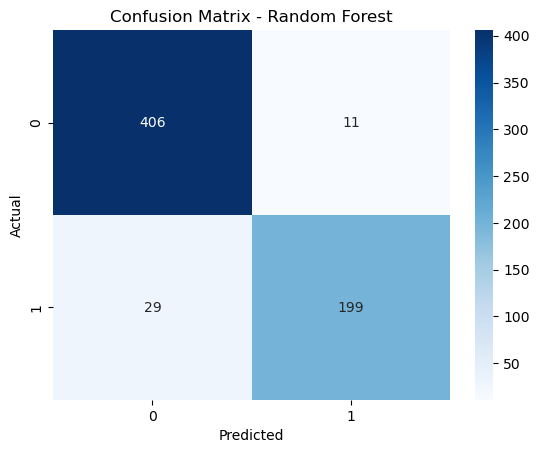

In [36]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

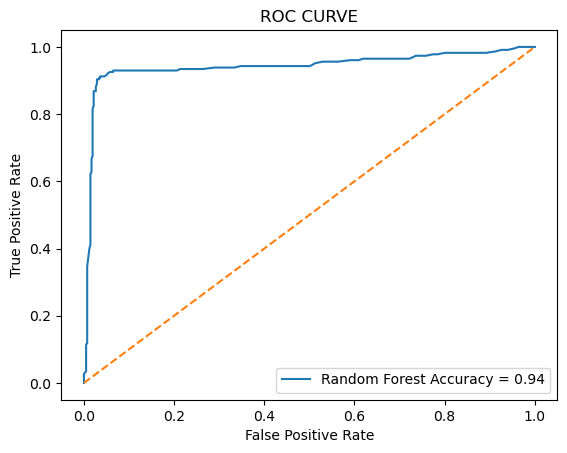

In [37]:
# ROC Curve
# Measures model’s ability to distinguish classes.


y_prob_rf = rf_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob_rf)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label='Random Forest Accuracy = %.2f' % roc_auc)
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

### Feature Importance

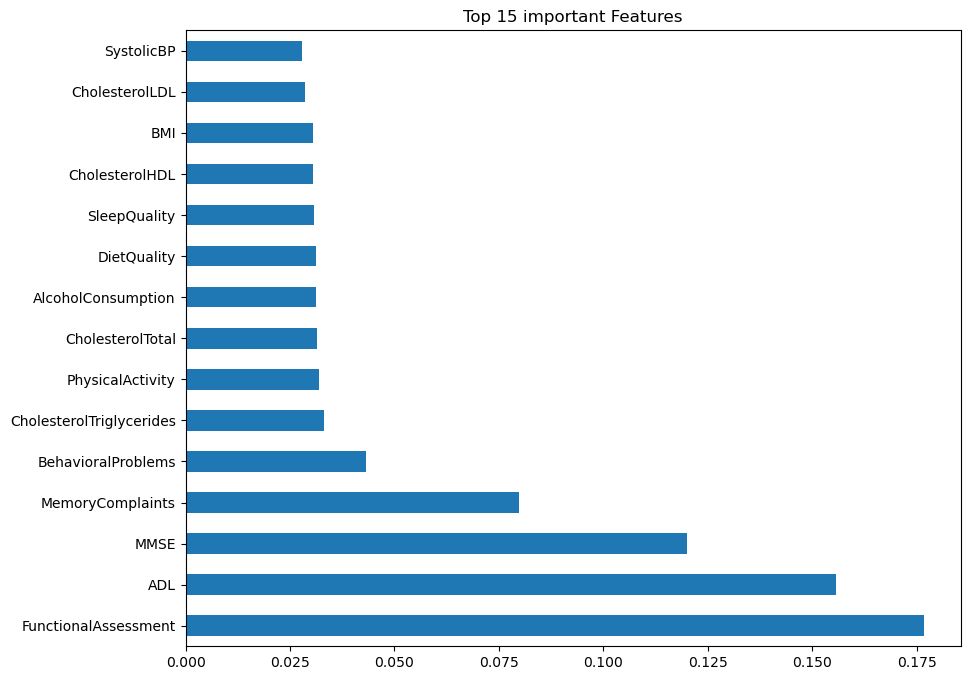

FunctionalAssessment        0.176702
ADL                         0.155731
MMSE                        0.120157
MemoryComplaints            0.079921
BehavioralProblems          0.043115
CholesterolTriglycerides    0.033106
PhysicalActivity            0.031915
CholesterolTotal            0.031417
AlcoholConsumption          0.031224
DietQuality                 0.031158
dtype: float64

In [38]:
# Feature Importance
# To identify most influential predictors

importances = pd.Series(rf_model.feature_importances_, index = X.columns)
important_features = importances.sort_values(ascending=False)

plt.figure(figsize=(10,8))
important_features.head(15).plot(kind='barh')
plt.title("Top 15 important Features")
plt.show()

important_features.head(10)

In [39]:
import joblib

joblib.dump(rf_model, "alzheimers_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

#### We save: trained model, scaler,These will be used in deployment

In [40]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [41]:
from pickle import dump

In [44]:
dump(log_model, open('log_model.pkl', 'wb'))
dump(rf_model, open('rf_model.pkl', 'wb'))